# Connectivity measures from real BOLD

Each measure is defined and plotted right where it is introduced, so any of them can be edited
and re-run on its own. Everything is self-contained -- nothing is imported from
`connectivity_measures.py`.

Notation throughout: `x_i(t)` is region `i`'s BOLD signal over the window, `X` is the
`[num_regions, num_timepoints]` matrix, and every measure returns a `[num_regions, num_regions]`
matrix.

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.stats import rankdata
from scipy.special import ndtri

INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
WINDOW_SIZE = 200     # the window BrainLM sees: 10 patches x 20 TR
SUBJECT = 0

with h5py.File(INPUT_H5, "r") as f:
    sub_id = f["subject_ids"][SUBJECT].decode("utf-8")
    X = f["parcel_ts"][SUBJECT, :WINDOW_SIZE, :].T      # [regions, time]

num_regions, num_timepoints = X.shape
off_mask = ~np.eye(num_regions, dtype=bool)
matrices = {}                                           # filled in as we go

print(f"{sub_id}: {num_regions} regions x {num_timepoints} TRs, NaNs={np.isnan(X).sum()}")

Sub_0000: 424 regions x 200 TRs, NaNs=0


In [3]:
def show(name, matrix, title ,cmap="magma"):
    """Store and plot a measure. Color scaled on the off-diagonal, since the diagonal is
    almost always the maximum and would otherwise flatten everything else."""
    matrices[name] = matrix
    off = matrix[off_mask]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.15, 1]})
    im = axes[0].imshow(matrix, cmap=cmap, vmin=np.percentile(off, 1), vmax=np.percentile(off, 99))
    axes[0].set_title(name)
    axes[0].set_xlabel("target region"); axes[0].set_ylabel("source region")
    fig.colorbar(im, ax=axes[0], fraction=0.046)
    axes[1].hist(off, bins=80, color="tab:blue", alpha=0.8)
    axes[1].axvline(off.mean(), color="black", linestyle="--", linewidth=1)
    axes[1].set_title(f"off-diagonal: mean={off.mean():.4f}")
    axes[1].set_yticks([])
    fig.tight_layout()
    plt.savefig(f"./figures/{title}.png")
    plt.show()


def standardize(X):
    Z = X - X.mean(axis=1, keepdims=True)
    return Z / np.maximum(Z.std(axis=1, keepdims=True), 1e-12)


def normal_scores(X):
    """Rank-transform each region to Gaussian marginals (the Gaussian-copula transform)."""
    return ndtri(np.apply_along_axis(rankdata, 1, X) / (X.shape[1] + 1))

## The signal

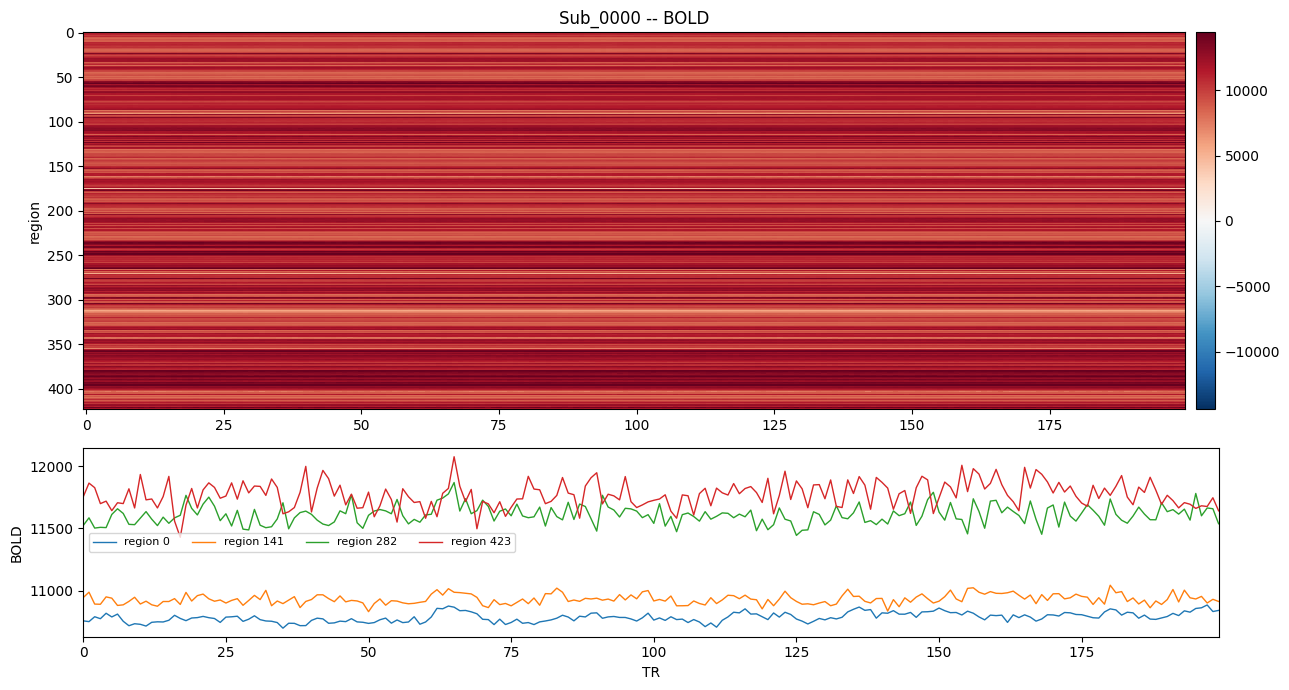

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [2, 1]})
v = np.percentile(np.abs(X), 98)
im = axes[0].imshow(X, aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v, interpolation="nearest")
axes[0].set_ylabel("region"); axes[0].set_title(f"{sub_id} -- BOLD")
fig.colorbar(im, ax=axes[0], fraction=0.02, pad=0.01)
for region in [0, num_regions // 3, 2 * num_regions // 3, num_regions - 1]:
    axes[1].plot(X[region], linewidth=1, label=f"region {region}")
axes[1].set_xlabel("TR"); axes[1].set_ylabel("BOLD")
axes[1].legend(fontsize=8, ncol=4); axes[1].set_xlim(0, num_timepoints - 1)
fig.tight_layout()
plt.savefig("./figures/bold.png")
plt.show()

## Pearson correlation (FC)

$$r_{ij} = \frac{\operatorname{cov}(x_i, x_j)}{\sigma_i \sigma_j}$$

Linear, instantaneous, symmetric, in $[-1, 1]$. The standard definition of functional
connectivity and the baseline everything else is compared against.

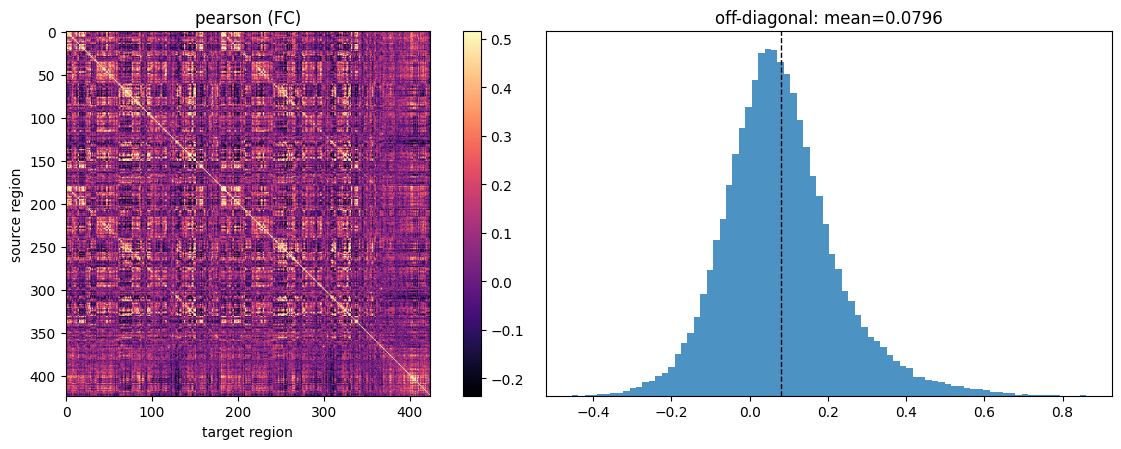

In [6]:
def pearson(X):
    return np.corrcoef(X)


show("pearson (FC)", pearson(X), "pearson")

## Spearman correlation

$$\rho_{ij} = r\big(\operatorname{rank}(x_i),\ \operatorname{rank}(x_j)\big)$$

Pearson applied to ranks, so it captures any *monotone* relationship rather than only a linear
one, and is insensitive to outliers.

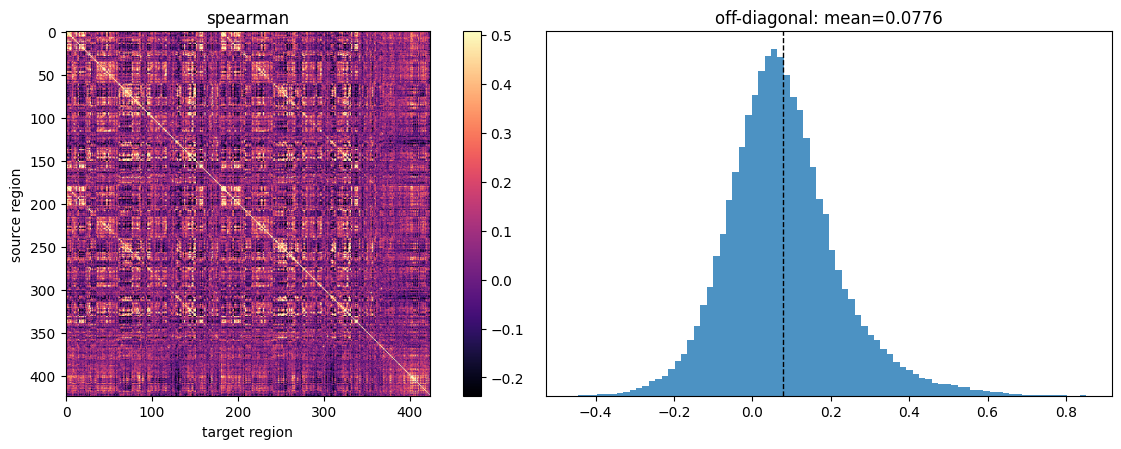

In [7]:
def spearman(X):
    return np.corrcoef(np.apply_along_axis(rankdata, 1, X))


show("spearman", spearman(X), "spearman")

## Partial correlation

With $P = \Sigma^{-1}$ the precision matrix,

$$p_{ij} = \frac{-P_{ij}}{\sqrt{P_{ii} P_{jj}}}$$

the correlation between $i$ and $j$ with *all other regions regressed out*, which separates
direct coupling from coupling inherited through a shared third region. With 424 regions and only
200 timepoints $\Sigma$ is singular, so it is shrunk toward its diagonal before inverting --
raise `shrinkage` for a more conservative estimate.

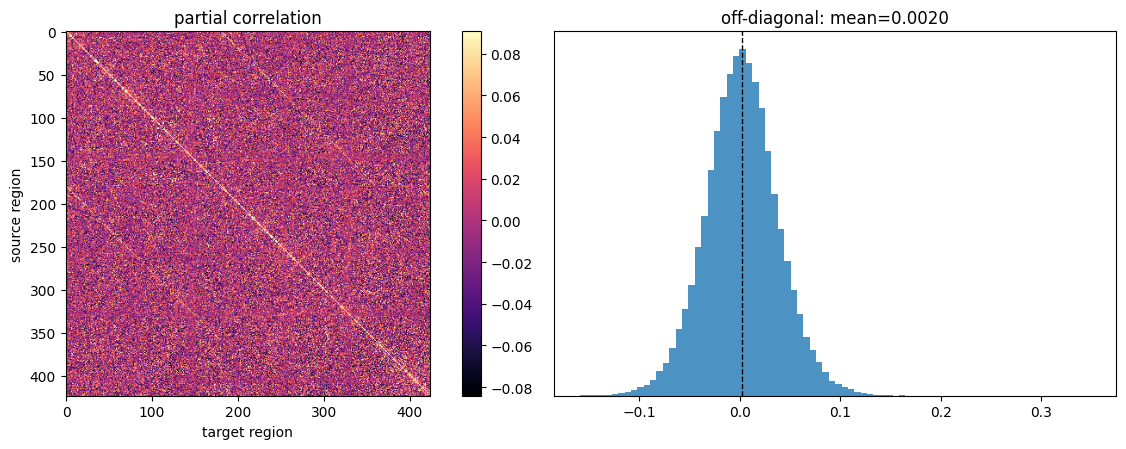

In [9]:
def partial_correlation(X, shrinkage=0.1):
    S = np.cov(standardize(X))
    S = (1 - shrinkage) * S + shrinkage * np.eye(len(S)) * np.trace(S) / len(S)
    P = np.linalg.inv(S)
    d = np.sqrt(np.diag(P))
    out = -P / np.outer(d, d)
    np.fill_diagonal(out, 1.0)
    return out


show("partial correlation", partial_correlation(X), "partial-correlation")

## Mutual information (Gaussian copula)

Rank-transform to Gaussian marginals, then for a bivariate Gaussian

$$I_{ij} = -\tfrac{1}{2}\log\big(1 - r_{ij}^2\big)$$

in nats. Invariant to any monotone rescaling of the signal, but still a monotone function of the
copula correlation -- so it ranks pairs much like Spearman, on a different scale. Self-MI is
infinite, so the diagonal is capped at the largest off-diagonal value.

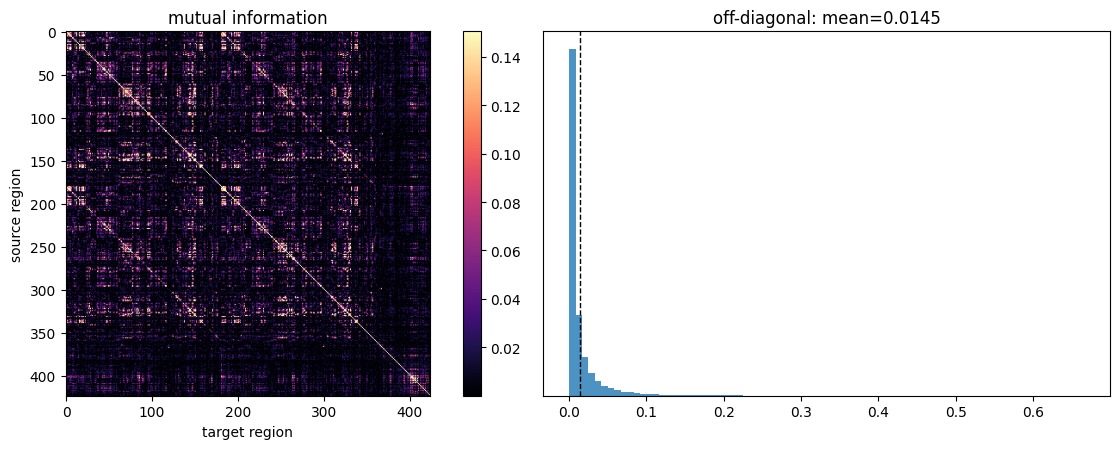

In [10]:
def mutual_information(X):
    r = np.corrcoef(normal_scores(X))
    mi = -0.5 * np.log(np.clip(1 - r ** 2, 1e-12, None))
    np.fill_diagonal(mi, mi[~np.eye(len(mi), dtype=bool)].max())
    return mi


show("mutual information", mutual_information(X), "mutual-information")

## Phase locking value (PLV)

Take the analytic signal $x_i(t) + i\,\mathcal{H}[x_i](t)$ via the Hilbert transform and let
$\phi_i(t)$ be its phase. Then

$$\mathrm{PLV}_{ij} = \Big| \frac{1}{T}\sum_t e^{\,i(\phi_i(t) - \phi_j(t))} \Big|$$

$1$ means the phase difference is constant, $0$ means it is uniformly spread. Amplitude is
discarded entirely -- two regions can be phase-locked no matter how different their signal
strengths.

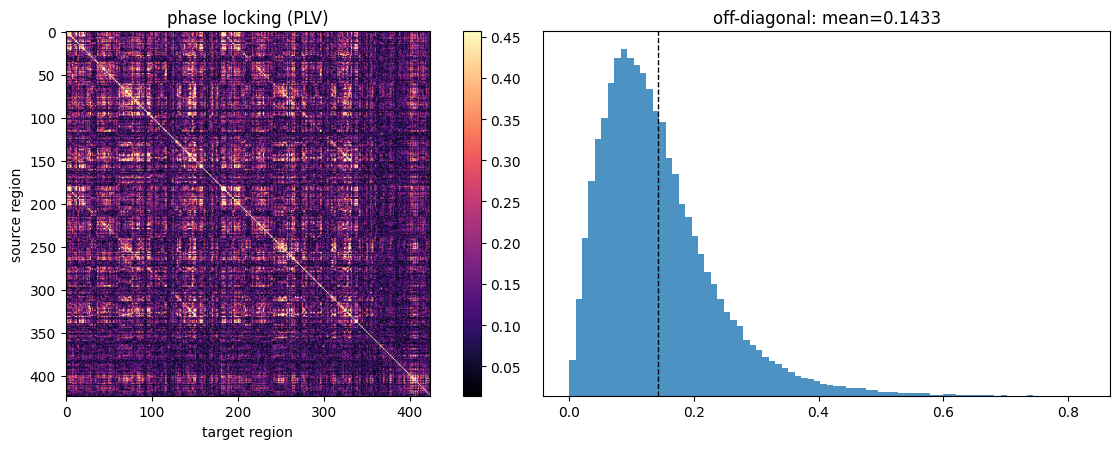

In [11]:
def phases(X):
    return np.angle(hilbert(standardize(X), axis=1))


def phase_locking_value(X):
    z = np.exp(1j * phases(X))
    return np.abs(z @ z.conj().T) / X.shape[1]


show("phase locking (PLV)", phase_locking_value(X), "PLV")

## Phase lag index (PLI)

$$\mathrm{PLI}_{ij} = \Big| \frac{1}{T}\sum_t \operatorname{sign}\big(\sin(\phi_i(t) - \phi_j(t))\big) \Big|$$

Only the *sign* of the phase difference counts, so a consistent zero-lag relationship contributes
nothing. That makes PLI insensitive to instantaneous shared signal and responsive to genuine
lead-lag structure instead.

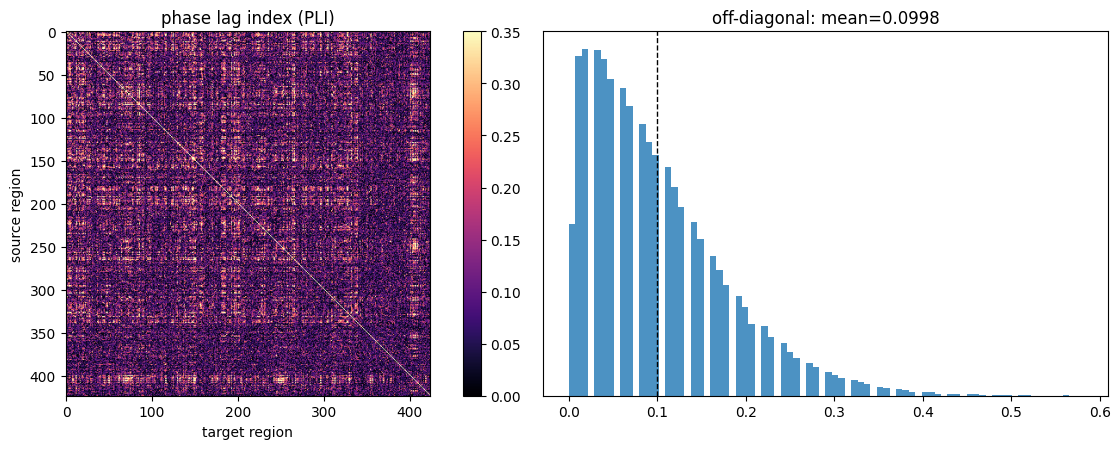

In [12]:
def phase_lag_index(X):
    phi = phases(X)
    out = np.empty((len(phi), len(phi)))
    for i in range(len(phi)):
        out[i] = np.abs(np.mean(np.sign(np.sin(phi[i] - phi)), axis=1))
    np.fill_diagonal(out, 1.0)
    return out


show("phase lag index (PLI)", phase_lag_index(X), "PLI")

## Granger causality

Predict $x_j(t)$ from its own past, then again with $x_i$'s past added, and compare the residual
variances:

$$G_{ij} = \log \frac{\operatorname{var}(\varepsilon_j \mid x_j^{\text{past}})}
{\operatorname{var}(\varepsilon_j \mid x_j^{\text{past}}, x_i^{\text{past}})}$$

$G_{ij} > 0$ means $i$'s history helps forecast $j$ beyond what $j$'s own history gives.
**Directed.** Order 1, solved in closed form for all pairs at once.

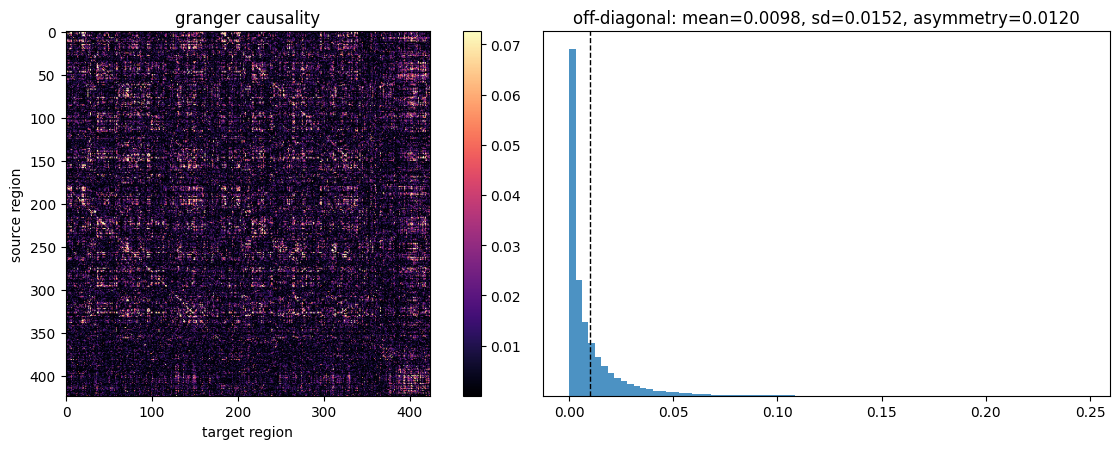

In [11]:
def granger_causality(X, lag=1):
    Z = standardize(X)
    past, future = Z[:, :-lag], Z[:, lag:]
    past = past - past.mean(axis=1, keepdims=True)
    future = future - future.mean(axis=1, keepdims=True)

    gram = past @ past.T                       # past_i . past_j
    cross = past @ future.T                    # past_i . future_j
    own_var, own_cross = np.diag(gram), np.diag(cross)
    target_var = np.einsum("it,it->i", future, future)

    restricted = target_var - own_cross ** 2 / np.maximum(own_var, 1e-12)

    uu, vv, uv = own_var[None, :], own_var[:, None], gram
    uy, vy = own_cross[None, :], cross
    det = uu * vv - uv ** 2
    det = np.where(np.abs(det) < 1e-12, np.nan, det)
    a = (vv * uy - uv * vy) / det
    b = (uu * vy - uv * uy) / det
    full = target_var[None, :] - a * uy - b * vy

    gc = np.log(np.maximum(restricted[None, :], 1e-12) / np.maximum(full, 1e-12))
    gc = np.nan_to_num(gc, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(gc, 0.0)
    return np.maximum(gc, 0.0)


show("granger causality", granger_causality(X))

## O-information

For a set $X^n$ of $n$ variables (Rosas et al. 2019; used in Herzog et al. 2025):

$$\Omega(X^n) = (n-2)H(X^n) + \sum_{j=1}^{n}\big[H(X_j) - H(X^n_{-j})\big]$$

$\Omega > 0$ is **redundancy**-dominated, $\Omega < 0$ **synergy**-dominated. Using Gaussian
copula entropies every term is a log-determinant, the $(2\pi e)$ constants cancel, and with
$|R_{-j}| = |R|\,(R^{-1})_{jj}$ the whole thing collapses to

$$\Omega = -\log|R| - \tfrac{1}{2}\sum_j \log (R^{-1})_{jj}$$

This is a property of a *set*, not a pair, so making a matrix needs a choice. Herzog et al. seed
a greedy search from **every pair**, repeatedly adding whichever region most decreases (or
increases) $\Omega$, then report the best value over seeds. We keep the per-seed value: entry
$(i,j)$ is $\Omega$ of the set grown from the pair $(i,j)$.

Growing a set by one region is a bordered rank-1 update, so each step is a matrix multiply
rather than thousands of determinants:

$$s = 1 - b^\top A^{-1} b, \qquad |M| = |A|\,s, \qquad
\operatorname{diag}(M^{-1}) = \big[\operatorname{diag}(A^{-1}) + (A^{-1}b)^2/s,\ 1/s\big]$$

`max_order` caps the set size (the paper grows to 30 and finds peak synergy around order 7-12).
Takes about a minute at the default.

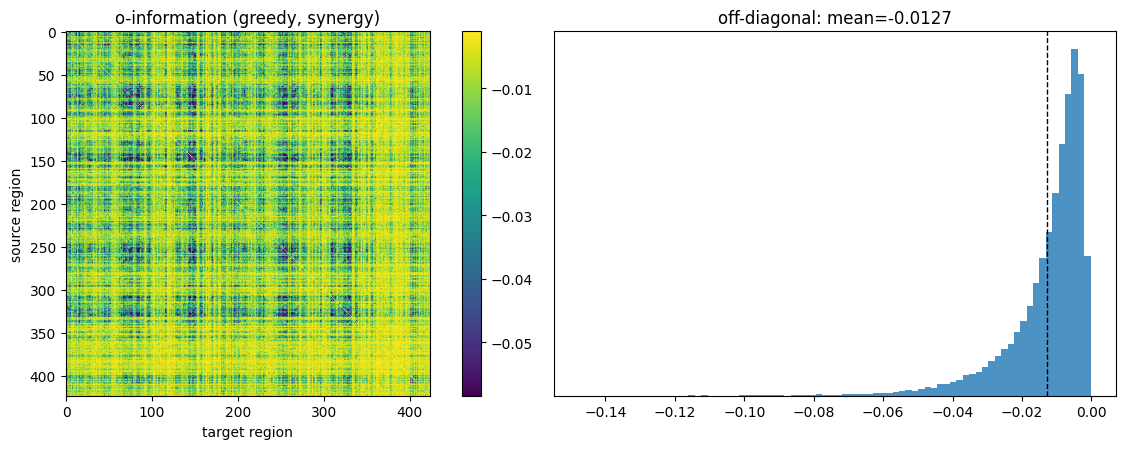

In [6]:
def omega_of_extensions(R, sets, inv, logdet, diag_inv):
    b = R[sets, :]
    u = np.einsum("cij,cjn->cin", inv, b)
    s = np.clip(1.0 - np.einsum("cin,cin->cn", b, u), 1e-10, None)
    diag_ext = diag_inv[:, :, None] + u ** 2 / s[:, None, :]
    sum_log = np.sum(np.log(np.clip(diag_ext, 1e-12, None)), axis=1) + np.log(1.0 / s)
    return -(logdet[:, None] + np.log(s)) - 0.5 * sum_log


def set_statistics(R, sets, ridge=1e-6):
    sub = R[sets[:, :, None], sets[:, None, :]] + ridge * np.eye(sets.shape[1])
    inv = np.linalg.inv(sub)
    _, logdet = np.linalg.slogdet(sub)
    return inv, logdet, np.einsum("...ii->...i", inv)


def o_information(X, max_order=10, mode="min", chunk=2048):
    R = np.corrcoef(normal_scores(X))
    n = len(R)
    source, target = np.triu_indices(n, k=1)
    out = np.zeros((n, n))
    pick = np.argmin if mode == "min" else np.argmax
    blocked = np.inf if mode == "min" else -np.inf

    for start in range(0, len(source), chunk):
        i, j = source[start:start + chunk], target[start:start + chunk]
        sets = np.stack([i, j], axis=1)
        rows = np.arange(len(sets))
        while sets.shape[1] < max_order:
            inv, logdet, diag_inv = set_statistics(R, sets)
            cand = omega_of_extensions(R, sets, inv, logdet, diag_inv)
            cand[rows[:, None], sets] = blocked
            best = pick(cand, axis=1)
            omega = cand[rows, best]
            sets = np.concatenate([sets, best[:, None]], axis=1)
        out[i, j] = out[j, i] = omega
    return out


show("o-information (greedy, synergy)", o_information(X, max_order=3, mode="min"), "o-info" ,cmap="viridis")

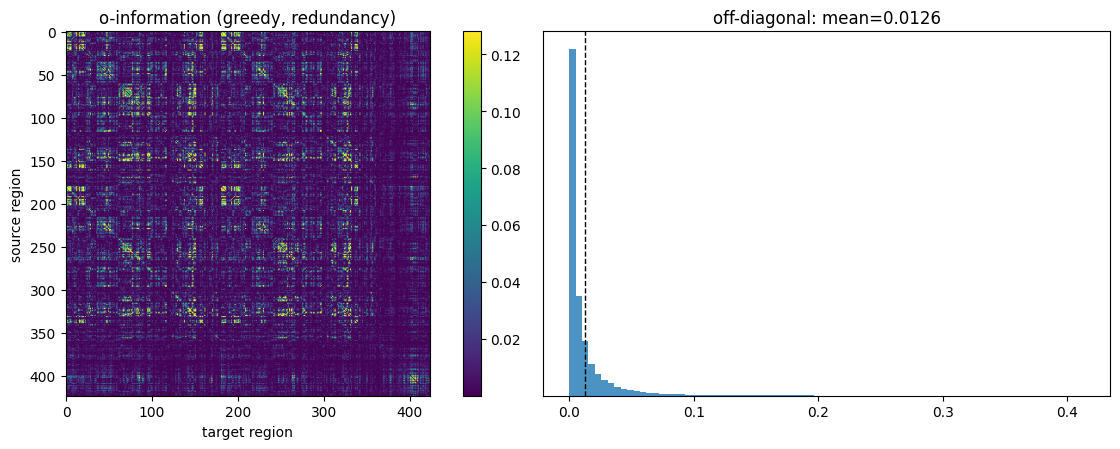

In [7]:
show("o-information (greedy, redundancy)", o_information(X, max_order=3, mode="max"), "o-info-redundancy" ,cmap="viridis")

### O-information, cheap alternative

Averaging the triplet $\Omega(i,j,k)$ over every third region $k$ instead of searching. At
$n=3$ the closed form is just

$$\Omega(i,j,k) = \tfrac{1}{2}\Big[\log|R_{ijk}| - \log(1-r_{ij}^2) - \log(1-r_{ik}^2) - \log(1-r_{jk}^2)\Big]$$

with $|R_{ijk}| = 1 + 2r_{ij}r_{ik}r_{jk} - r_{ij}^2 - r_{ik}^2 - r_{jk}^2$. Exhaustive over the
third variable rather than greedy, and runs in about a second -- worth comparing against the
greedy version above.

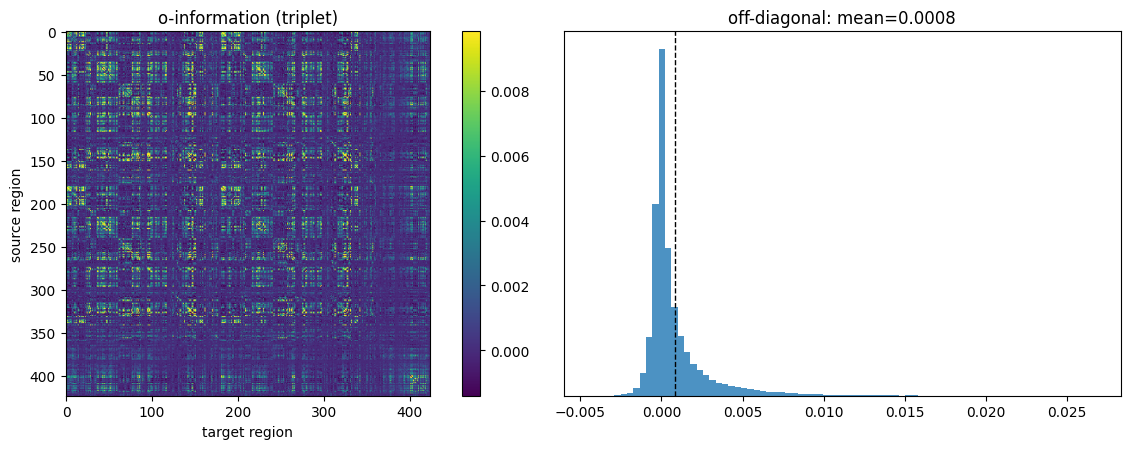

In [8]:
def o_information_triplet(X):
    r = np.corrcoef(X)
    n = len(r)
    r2 = np.clip(r ** 2, 0, 1 - 1e-9)
    log_pair = np.log(1 - r2)
    total, count = np.zeros((n, n)), np.zeros((n, n))
    for k in range(n):
        rik, rjk = r[:, k][:, None], r[:, k][None, :]
        det = 1 + 2 * r * rik * rjk - r2 - rik ** 2 - rjk ** 2
        omega = 0.5 * (np.log(np.clip(det, 1e-12, None)) - log_pair
                       - np.log(np.clip(1 - rik ** 2, 1e-12, None))
                       - np.log(np.clip(1 - rjk ** 2, 1e-12, None)))
        valid = np.ones((n, n), dtype=bool)
        valid[k, :] = False; valid[:, k] = False
        total += np.where(valid, omega, 0.0)
        count += valid
    out = total / np.maximum(count, 1)
    np.fill_diagonal(out, 0.0)
    return out


show("o-information (triplet)", o_information_triplet(X), "o-info-triplet" ,cmap="viridis")

## Comparing them

Measures that rank region pairs the same way carry the same information, whatever their scales
look like.

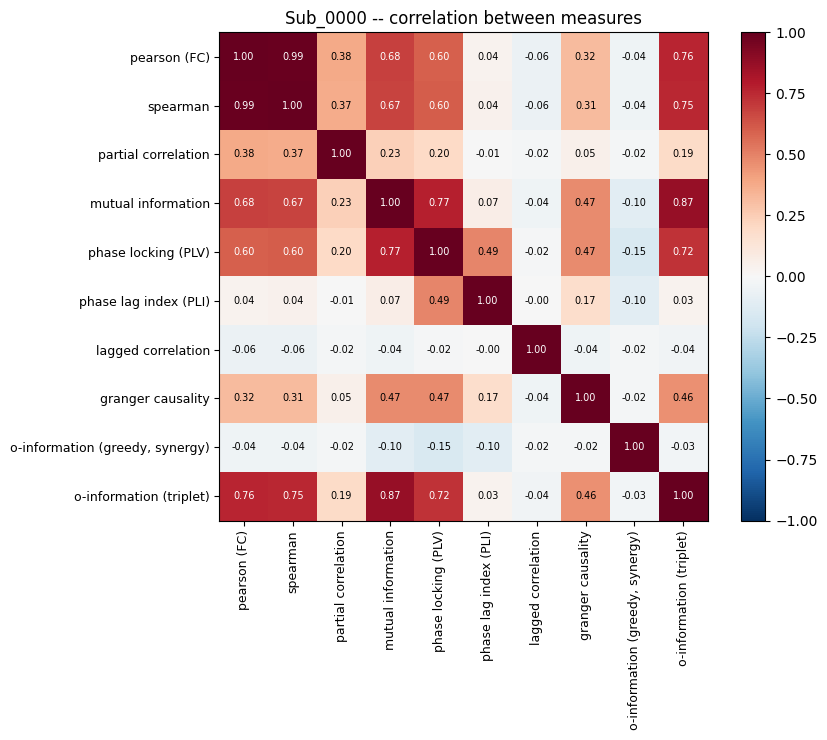

In [14]:
names = list(matrices)
agreement = np.array([[np.corrcoef(matrices[a][off_mask], matrices[b][off_mask])[0, 1]
                       for b in names] for a in names])

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(agreement, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=9)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=9)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f"{agreement[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(agreement[i, j]) > 0.55 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title(f"{sub_id} -- correlation between measures")
fig.tight_layout()
plt.show()

## Structure by region-lag

Mean $|M_{i,i+L}|$ for each lag $L$. A peak away from $L = 0$ means regions a fixed index apart
are unusually coupled -- for this atlas that is the homotopic (cross-hemisphere) separation, and
it is what shows up as a displaced band in the attention matrices.

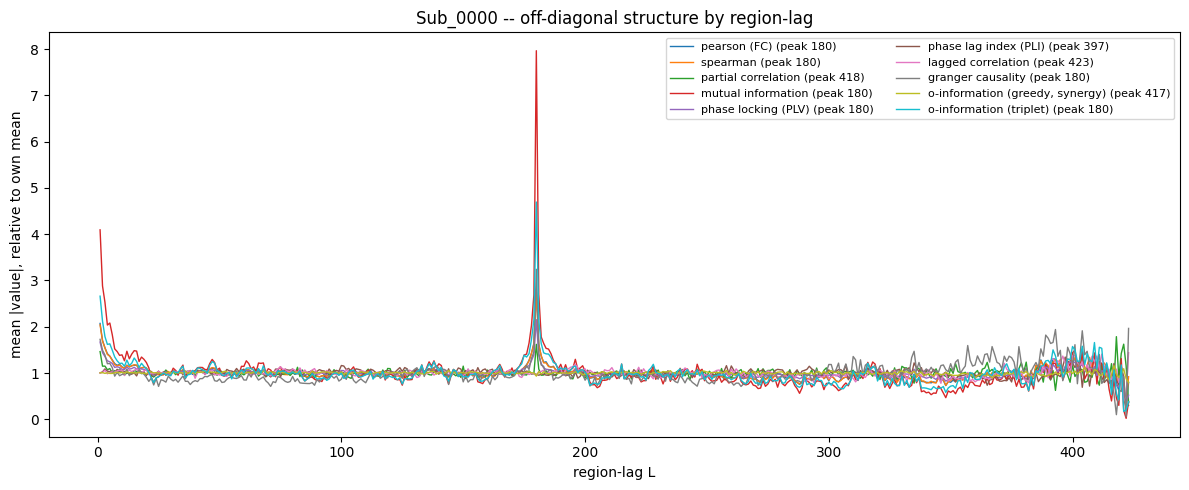

In [15]:
lags = np.arange(1, num_regions)

fig, ax = plt.subplots(figsize=(12, 5))
for name, matrix in matrices.items():
    profile = np.array([np.abs(np.diag(matrix, lag)).mean() for lag in lags])
    peak = int(lags[np.argmax(profile)])
    ax.plot(lags, profile / profile.mean(), linewidth=1, label=f"{name} (peak {peak})")
ax.set_xlabel("region-lag L"); ax.set_ylabel("mean |value|, relative to own mean")
ax.set_title(f"{sub_id} -- off-diagonal structure by region-lag")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()